# Semi-Supervised Learning

Semi-Supervised Learning (SSL) studies learning problems where only a small portion of the training data is labeled, while a much larger portion is unlabeled.

The goal is to exploit both labeled and unlabeled examples to build a better predictive model.

This notebook covers:

- The foundations of semi-supervised learning
- SSL assumptions
- Self-training
- Pseudo-labeling
- Label propagation
- Label spreading
- Confidence-based learning
- Decision-boundary visualization
- The effect of labeled-data availability
- Failure modes and practical considerations

## Learning Objectives

By the end of this notebook, we should be able to:

1. Explain what semi-supervised learning is.
2. Distinguish semi-supervised learning from supervised and unsupervised learning.
3. Understand the assumptions that make SSL possible.
4. Explain self-training and pseudo-labeling.
5. Implement label propagation.
6. Implement label spreading.
7. Compare SSL methods with a supervised baseline.
8. Analyze how the amount of labeled data affects performance.
9. Understand confidence thresholds in pseudo-labeling.
10. Identify situations where semi-supervised learning can fail.

## What Is Semi-Supervised Learning?

Suppose we have a dataset containing two types of examples:

- A small labeled dataset
- A large unlabeled dataset

The labeled dataset is:

$$
\mathcal{D}_L =
\{(x_i,y_i)\}_{i=1}^{n_L}
$$

where both the input $x_i$ and target $y_i$ are known.

The unlabeled dataset is:

$$
\mathcal{D}_U =
\{x_i\}_{i=n_L+1}^{n_L+n_U}
$$

where the target values are unknown.

The complete training data can therefore be represented as:

$$
\mathcal{D}
=
\mathcal{D}_L
\cup
\mathcal{D}_U
$$

Usually:

$$
n_U \gg n_L
$$

The central idea of semi-supervised learning is to use information contained in the unlabeled examples together with the labeled examples.

This can be useful when obtaining labels is expensive, slow, or requires human expertise.

## Supervised, Unsupervised, and Semi-Supervised Learning

### Supervised Learning

Training data contains labels for every example.

$$
\{(x_i,y_i)\}_{i=1}^{n}
$$

The model learns:

$$
f:X\rightarrow Y
$$

---

### Unsupervised Learning

No target labels are provided.

$$
\{x_i\}_{i=1}^{n}
$$

The goal is to discover structure such as:

- clusters
- latent representations
- density structure
- anomalies

---

### Semi-Supervised Learning

Only part of the dataset is labeled.

$$
\{(x_i,y_i)\}_{i=1}^{n_L}
\cup
\{x_i\}_{i=n_L+1}^{n}
$$

The model attempts to exploit the structure of both labeled and unlabeled data.

## Why Use Semi-Supervised Learning?

In many real-world problems, unlabeled data is abundant while labeled data is expensive.

For example:

- Images can be collected automatically, but labeling them requires humans.
- Medical records may require domain experts for annotation.
- Web pages are easy to collect but expensive to categorize.
- Speech recordings can be collected at scale but transcription is costly.

Consider a dataset containing:

$$
100,000
$$

examples.

Suppose only:

$$
1,000
$$

examples have labels.

A purely supervised approach would use only the 1,000 labeled examples.

Semi-supervised learning attempts to extract additional information from the remaining:

$$
99,000
$$

unlabeled examples.

The unlabeled data does **not** automatically provide correct labels.

Instead, SSL relies on assumptions about the structure of the data.

## Fundamental Assumptions

Several assumptions are commonly used to justify semi-supervised learning.

### 1. Smoothness Assumption

If two examples are close to each other in the input space, their outputs are likely to be similar.

$$
d(x_i,x_j)\text{ small}
\Rightarrow
P(y_i=y_j)\text{ high}
$$

---

### 2. Cluster Assumption

Examples belonging to the same high-density cluster are likely to share the same label.

A decision boundary should preferably pass through low-density regions rather than through dense clusters.

---

### 3. Manifold Assumption

High-dimensional observations may lie approximately on a lower-dimensional manifold.

Instead of learning directly in the full input space, the model can exploit the underlying geometry of the data.

These assumptions are important because unlabeled data is useful only when its structure provides information about the target variable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.semi_supervised import (
    SelfTrainingClassifier,
    LabelPropagation,
    LabelSpreading
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.base import clone

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

## Synthetic Dataset

We will use the two-moons dataset.

The two-moons dataset is useful for demonstrating semi-supervised learning because its classes have a nonlinear geometric structure.

This allows us to see why methods that exploit the geometry of the data can outperform a simple linear classifier.

In [2]:
X, y = make_moons(
    n_samples=1200,
    noise=0.15,
    random_state=RANDOM_STATE
)

X.shape, y.shape

((1200, 2), (1200,))

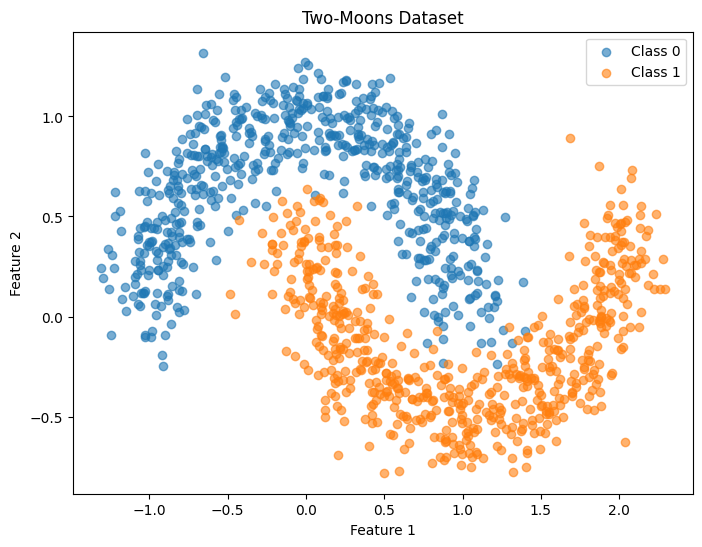

In [3]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    alpha=0.6,
    label="Class 0"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    alpha=0.6,
    label="Class 1"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Two-Moons Dataset")
plt.legend()
plt.show()

## Train-Test Split

We first separate the data into training and test sets.

The test labels remain completely hidden from the learning algorithms.

The training set will later be divided into:

- labeled training examples
- unlabeled training examples

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 840
Test samples: 360


## Creating a Partially Labeled Training Set

To simulate a semi-supervised problem, we hide the labels of most training examples.

Only a small percentage of training examples will remain labeled.

For this experiment, we will keep:

$$
10\%
$$

of the training data labeled.

The remaining:

$$
90\%
$$

will be treated as unlabeled.

In scikit-learn's semi-supervised estimators, unlabeled samples are represented using:

$$
y=-1
$$

In [5]:
labeled_fraction = 0.10

n_labeled = int(len(X_train) * labeled_fraction)

rng = np.random.default_rng(RANDOM_STATE)

labeled_indices = rng.choice(
    len(X_train),
    size=n_labeled,
    replace=False
)

y_train_partial = np.full(
    len(y_train),
    -1,
    dtype=int
)

y_train_partial[labeled_indices] = y_train[labeled_indices]

print("Total training samples:", len(y_train))
print("Labeled samples:", np.sum(y_train_partial != -1))
print("Unlabeled samples:", np.sum(y_train_partial == -1))

Total training samples: 840
Labeled samples: 84
Unlabeled samples: 756


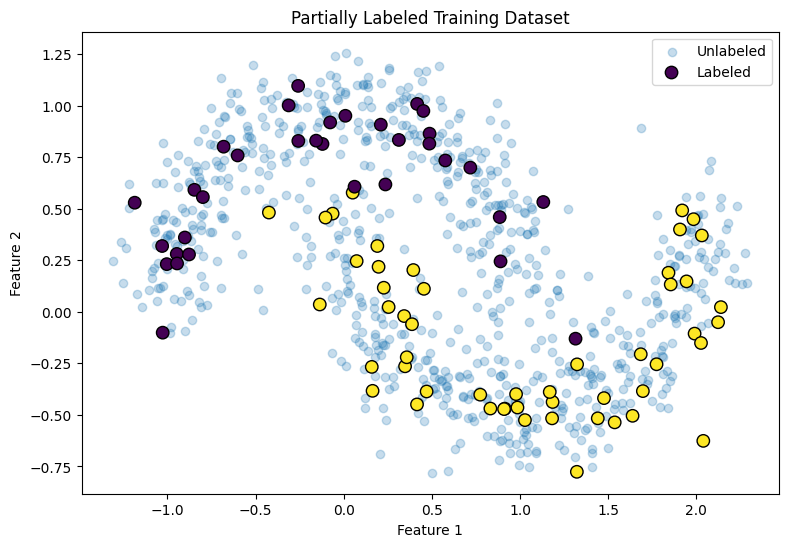

In [6]:
plt.figure(figsize=(9, 6))

unlabeled_mask = y_train_partial == -1
labeled_mask = y_train_partial != -1

plt.scatter(
    X_train[unlabeled_mask, 0],
    X_train[unlabeled_mask, 1],
    alpha=0.25,
    label="Unlabeled"
)

plt.scatter(
    X_train[labeled_mask, 0],
    X_train[labeled_mask, 1],
    c=y_train_partial[labeled_mask],
    s=80,
    edgecolor="black",
    label="Labeled"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Partially Labeled Training Dataset")
plt.legend()
plt.show()

## Supervised Baseline

Before using unlabeled data, we establish a baseline.

The baseline model receives only the labeled examples.

We will use logistic regression.

This is intentionally a simple model because the two-moons dataset has a nonlinear decision boundary.

The baseline gives us a reference point against which we can compare SSL methods.

In [7]:
X_labeled = X_train[labeled_mask]
y_labeled = y_train_partial[labeled_mask]

supervised_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=RANDOM_STATE)
)

supervised_model.fit(
    X_labeled,
    y_labeled
)

supervised_pred = supervised_model.predict(X_test)

supervised_accuracy = accuracy_score(
    y_test,
    supervised_pred
)

print(f"Supervised accuracy: {supervised_accuracy:.4f}")

Supervised accuracy: 0.8750


## Self-Training

Self-training is one of the simplest semi-supervised learning strategies.

The basic procedure is:

1. Train a model using the labeled examples.
2. Predict labels for the unlabeled examples.
3. Identify predictions with sufficiently high confidence.
4. Add those pseudo-labeled examples to the labeled dataset.
5. Retrain the model.
6. Repeat the process.

Suppose the classifier produces:

$$
P(y=k\mid x)
$$

for each class.

An unlabeled example can be assigned a pseudo-label when:

$$
\max_k P(y=k\mid x) \geq \tau
$$

where $\tau$ is the confidence threshold.

A high threshold makes pseudo-labeling more conservative.

A low threshold allows more unlabeled examples to enter training but increases the risk of incorrect pseudo-labels.

In [8]:
base_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    )
)

self_training_model = SelfTrainingClassifier(
    estimator=base_model,
    threshold=0.90,
    max_iter=20
)

self_training_model.fit(
    X_train,
    y_train_partial
)

self_training_pred = self_training_model.predict(X_test)

self_training_accuracy = accuracy_score(
    y_test,
    self_training_pred
)

print(f"Self-training accuracy: {self_training_accuracy:.4f}")

Self-training accuracy: 0.8694


In [9]:
transduced_labels = self_training_model.transduction_

n_original_labeled = np.sum(y_train_partial != -1)
n_pseudo_labeled = np.sum(
    (y_train_partial == -1) &
    (transduced_labels != -1)
)

print("Original labeled samples:", n_original_labeled)
print("Pseudo-labeled samples:", n_pseudo_labeled)
print("Total labeled after self-training:", 
      n_original_labeled + n_pseudo_labeled)

Original labeled samples: 84
Pseudo-labeled samples: 588
Total labeled after self-training: 672


## Pseudo-Labeling

Pseudo-labeling follows a similar idea but is often implemented explicitly.

A model trained on labeled data predicts labels for unlabeled examples.

For each unlabeled example:

$$
\hat{y}
=
\arg\max_k P(y=k\mid x)
$$

The prediction is accepted only when confidence exceeds a threshold:

$$
\max_k P(y=k\mid x)\geq\tau
$$

These predicted labels are called **pseudo-labels** because they were generated by the model rather than provided by a human annotator.

A major danger is confirmation bias:

$$
\text{incorrect prediction}
\rightarrow
\text{pseudo-label}
\rightarrow
\text{retraining}
\rightarrow
\text{stronger incorrect prediction}
$$

Therefore, confidence thresholds and validation are important.

In [10]:
base_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    )
)

base_model.fit(
    X_labeled,
    y_labeled
)

unlabeled_mask = y_train_partial == -1

X_unlabeled = X_train[unlabeled_mask]

probabilities = base_model.predict_proba(X_unlabeled)

pseudo_labels = np.argmax(probabilities, axis=1)

confidence = np.max(probabilities, axis=1)

threshold = 0.90

high_confidence_mask = confidence >= threshold

print("Unlabeled samples:", len(X_unlabeled))
print("High-confidence samples:", high_confidence_mask.sum())
print(
    "Percentage selected:",
    f"{100 * high_confidence_mask.mean():.2f}%"
)

Unlabeled samples: 756
High-confidence samples: 409
Percentage selected: 54.10%


In [11]:
X_pseudo = X_unlabeled[high_confidence_mask]
y_pseudo = pseudo_labels[high_confidence_mask]

X_augmented = np.vstack([
    X_labeled,
    X_pseudo
])

y_augmented = np.concatenate([
    y_labeled,
    y_pseudo
])

pseudo_label_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    )
)

pseudo_label_model.fit(
    X_augmented,
    y_augmented
)

pseudo_pred = pseudo_label_model.predict(X_test)

pseudo_accuracy = accuracy_score(
    y_test,
    pseudo_pred
)

print(f"Pseudo-labeling accuracy: {pseudo_accuracy:.4f}")

Pseudo-labeling accuracy: 0.8750


## Label Propagation

Label propagation takes a graph-based approach.

Each observation is treated as a node in a graph.

Similar observations are connected with stronger edges.

The labeled nodes provide class information that can propagate through the graph to nearby unlabeled nodes.

Conceptually:

$$
\text{labeled nodes}
\rightarrow
\text{similar unlabeled nodes}
\rightarrow
\text{additional labels}
$$

This approach is particularly useful when the geometry of the data is informative.

The method assumes that nearby examples are likely to have similar labels.

In [12]:
label_propagation_model = LabelPropagation(
    kernel="rbf",
    gamma=20,
    max_iter=1000
)

label_propagation_model.fit(
    X_train,
    y_train_partial
)

lp_pred = label_propagation_model.predict(X_test)

lp_accuracy = accuracy_score(
    y_test,
    lp_pred
)

print(f"Label Propagation accuracy: {lp_accuracy:.4f}")

Label Propagation accuracy: 0.9750


## Label Spreading

Label spreading is closely related to label propagation but uses a softer form of label assignment.

Instead of forcing the graph to preserve hard labels exactly, label spreading allows label information to diffuse through the graph.

The algorithm constructs relationships between samples and iteratively spreads class information.

This makes label spreading more robust to noisy labels than strict propagation in many situations.

In [13]:
label_spreading_model = LabelSpreading(
    kernel="rbf",
    gamma=20,
    alpha=0.2,
    max_iter=1000
)

label_spreading_model.fit(
    X_train,
    y_train_partial
)

ls_pred = label_spreading_model.predict(X_test)

ls_accuracy = accuracy_score(
    y_test,
    ls_pred
)

print(f"Label Spreading accuracy: {ls_accuracy:.4f}")

Label Spreading accuracy: 0.9889


## Comparing the Methods

We now compare:

1. Supervised learning using only labeled data
2. Self-training
3. Manual pseudo-labeling
4. Label propagation
5. Label spreading

The comparison is performed on the same held-out test set.

In [14]:
results = pd.DataFrame({
    "Method": [
        "Supervised",
        "Self-Training",
        "Pseudo-Labeling",
        "Label Propagation",
        "Label Spreading"
    ],
    "Accuracy": [
        supervised_accuracy,
        self_training_accuracy,
        pseudo_accuracy,
        lp_accuracy,
        ls_accuracy
    ]
})

results.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

,Method,Accuracy
0,Label Spreading,0.988889
1,Label Propagation,0.975000
2,Supervised,0.875000
3,Pseudo-Labeling,0.875000
4,Self-Training,0.869444


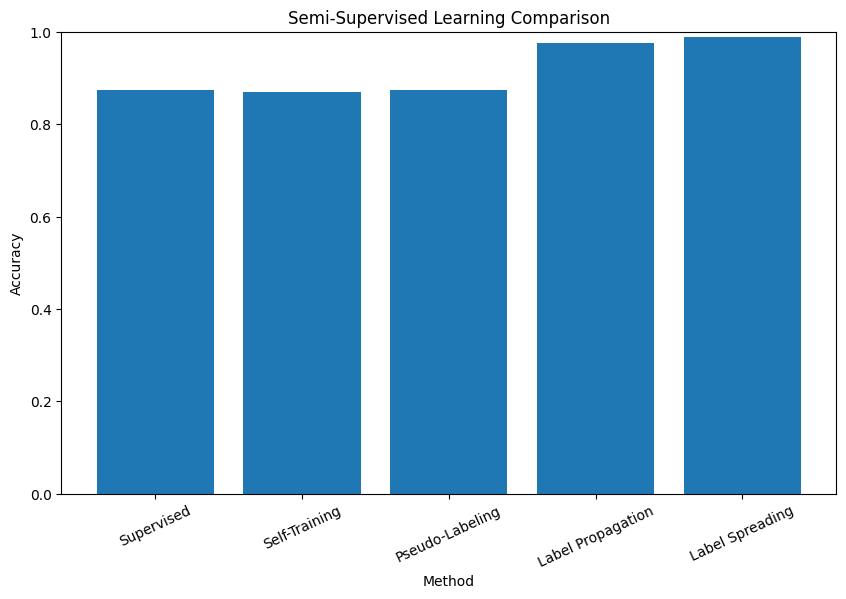

In [15]:
plt.figure(figsize=(10, 6))

plt.bar(
    results["Method"],
    results["Accuracy"]
)

plt.ylabel("Accuracy")
plt.xlabel("Method")
plt.title("Semi-Supervised Learning Comparison")
plt.ylim(0, 1)

plt.xticks(rotation=25)
plt.show()

## Effect of the Amount of Labeled Data

One of the most important questions in semi-supervised learning is:

> How much labeled data is actually necessary?

We will repeat the experiment using different labeled-data fractions.

For example:

$$
1\%,\ 5\%,\ 10\%,\ 20\%,\ 40\%
$$

We can then examine whether the unlabeled data helps especially when labeled data is scarce.

In [16]:
labeled_fractions = [
    0.01,
    0.05,
    0.10,
    0.20,
    0.40
]

experiment_results = []

for fraction in labeled_fractions:

    n_labeled = max(
        2,
        int(len(X_train) * fraction)
    )

    indices = rng.choice(
        len(X_train),
        size=n_labeled,
        replace=False
    )

    partial_labels = np.full(
        len(y_train),
        -1,
        dtype=int
    )

    partial_labels[indices] = y_train[indices]

    labeled_mask_exp = partial_labels != -1

    # Supervised
    model_supervised = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    )

    model_supervised.fit(
        X_train[labeled_mask_exp],
        partial_labels[labeled_mask_exp]
    )

    pred_supervised = model_supervised.predict(X_test)

    # Label Spreading
    model_spreading = LabelSpreading(
        kernel="rbf",
        gamma=20,
        alpha=0.2,
        max_iter=1000
    )

    model_spreading.fit(
        X_train,
        partial_labels
    )

    pred_spreading = model_spreading.predict(X_test)

    experiment_results.append({
        "Labeled Fraction": fraction,
        "Labeled Samples": n_labeled,
        "Supervised Accuracy": accuracy_score(
            y_test,
            pred_supervised
        ),
        "Label Spreading Accuracy": accuracy_score(
            y_test,
            pred_spreading
        )
    })

experiment_df = pd.DataFrame(experiment_results)

experiment_df

,Labeled Fraction,Labeled Samples,Supervised Accuracy,Label Spreading Accuracy
0,0.01,8,0.852778,0.930556
1,0.05,42,0.861111,0.991667
2,0.10,84,0.872222,0.994444
3,0.20,168,0.883333,0.988889
4,0.40,336,0.875000,0.988889


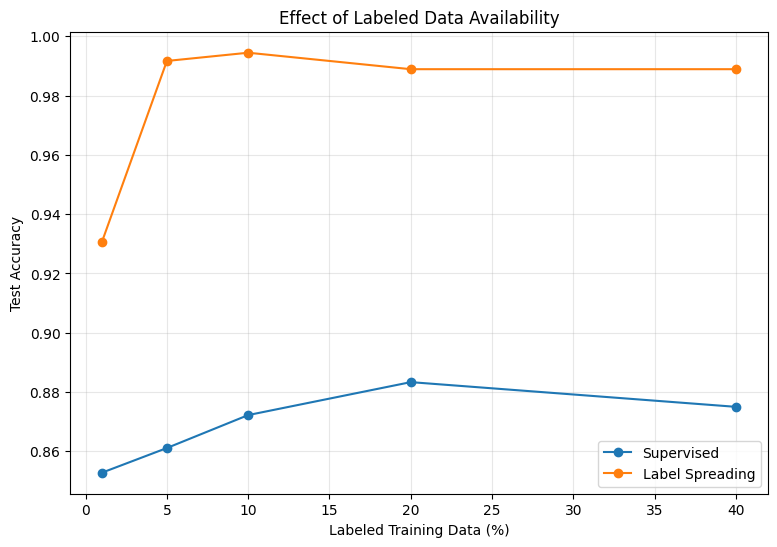

In [17]:
plt.figure(figsize=(9, 6))

plt.plot(
    experiment_df["Labeled Fraction"] * 100,
    experiment_df["Supervised Accuracy"],
    marker="o",
    label="Supervised"
)

plt.plot(
    experiment_df["Labeled Fraction"] * 100,
    experiment_df["Label Spreading Accuracy"],
    marker="o",
    label="Label Spreading"
)

plt.xlabel("Labeled Training Data (%)")
plt.ylabel("Test Accuracy")
plt.title("Effect of Labeled Data Availability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Confidence Threshold Analysis

Pseudo-labeling depends strongly on the confidence threshold.

Consider:

$$
\tau \in
\{0.50,0.60,0.70,0.80,0.90,0.95,0.99\}
$$

A lower threshold accepts more pseudo-labels.

A higher threshold accepts fewer pseudo-labels but attempts to improve pseudo-label quality.

There is therefore a trade-off:

$$
\text{coverage}
\leftrightarrow
\text{pseudo-label quality}
$$

In [18]:
thresholds = [
    0.50,
    0.60,
    0.70,
    0.80,
    0.90,
    0.95,
    0.99
]

threshold_results = []

for threshold in thresholds:

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE
        )
    )

    model.fit(
        X_labeled,
        y_labeled
    )

    probabilities = model.predict_proba(
        X_unlabeled
    )

    pseudo_labels = np.argmax(
        probabilities,
        axis=1
    )

    confidence = np.max(
        probabilities,
        axis=1
    )

    selected = confidence >= threshold

    if selected.sum() > 0:

        X_aug = np.vstack([
            X_labeled,
            X_unlabeled[selected]
        ])

        y_aug = np.concatenate([
            y_labeled,
            pseudo_labels[selected]
        ])

        final_model = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )

        final_model.fit(
            X_aug,
            y_aug
        )

        prediction = final_model.predict(X_test)

        accuracy = accuracy_score(
            y_test,
            prediction
        )

    else:
        accuracy = supervised_accuracy

    threshold_results.append({
        "Threshold": threshold,
        "Pseudo-Labels": selected.sum(),
        "Coverage": selected.mean(),
        "Accuracy": accuracy
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Pseudo-Labels,Coverage,Accuracy
0,0.50,756,1.000000,0.875000
1,0.60,691,0.914021,0.875000
2,0.70,629,0.832011,0.875000
3,0.80,559,0.739418,0.875000
4,0.90,409,0.541005,0.875000
5,0.95,274,0.362434,0.872222
6,0.99,44,0.058201,0.875000


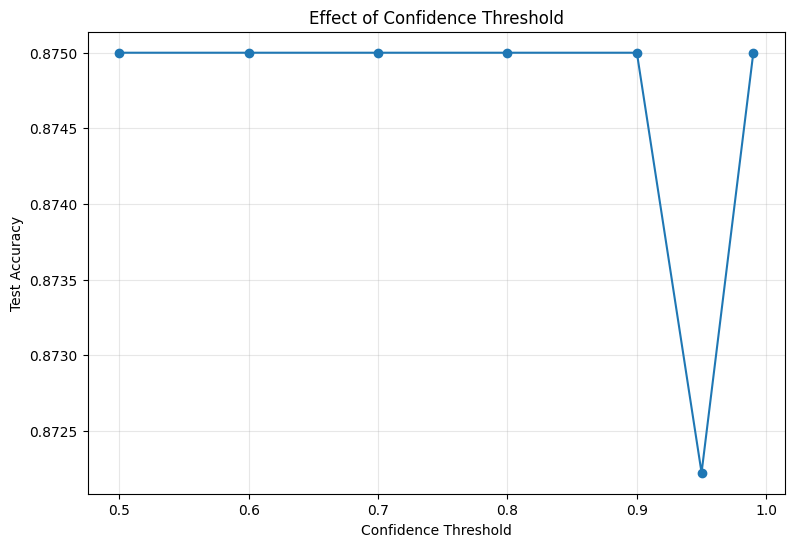

In [19]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Accuracy"],
    marker="o"
)

plt.xlabel("Confidence Threshold")
plt.ylabel("Test Accuracy")
plt.title("Effect of Confidence Threshold")
plt.grid(True, alpha=0.3)
plt.show()

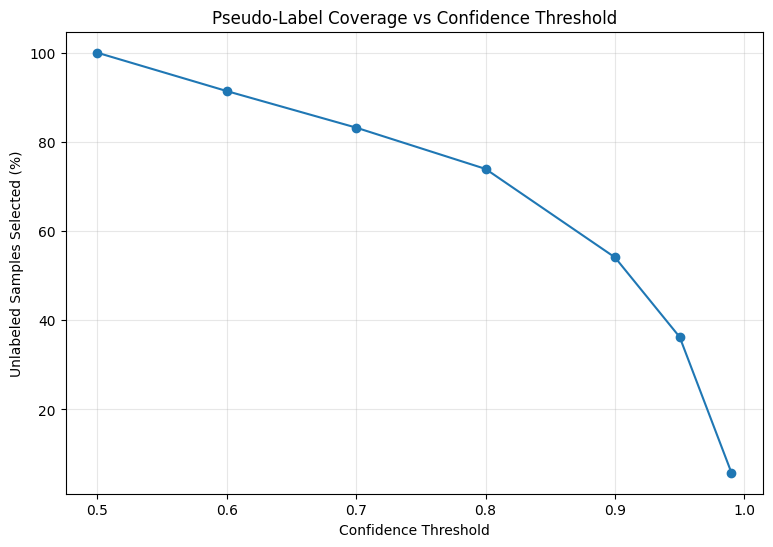

In [20]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Coverage"] * 100,
    marker="o"
)

plt.xlabel("Confidence Threshold")
plt.ylabel("Unlabeled Samples Selected (%)")
plt.title("Pseudo-Label Coverage vs Confidence Threshold")
plt.grid(True, alpha=0.3)
plt.show()

## Decision Boundary Comparison

Visualization is particularly important for semi-supervised learning.

We will compare the decision boundaries learned by:

- Supervised learning
- Self-training
- Label propagation
- Label spreading

This allows us to visually inspect how unlabeled data changes the learned structure.

In [21]:
def plot_decision_boundary(
    model,
    X,
    y,
    title,
    labeled_mask=None
):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    if hasattr(model, "predict_proba"):
        Z = model.predict_proba(grid)[:, 1]
    else:
        Z = model.predict(grid)

    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        Z,
        levels=30,
        alpha=0.25
    )

    if labeled_mask is not None:
        plt.scatter(
            X[~labeled_mask, 0],
            X[~labeled_mask, 1],
            c=y[~labeled_mask],
            alpha=0.15,
            s=20
        )

        plt.scatter(
            X[labeled_mask, 0],
            X[labeled_mask, 1],
            c=y[labeled_mask],
            edgecolor="black",
            s=70
        )
    else:
        plt.scatter(
            X[:, 0],
            X[:, 1],
            c=y,
            edgecolor="black",
            s=30
        )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.show()

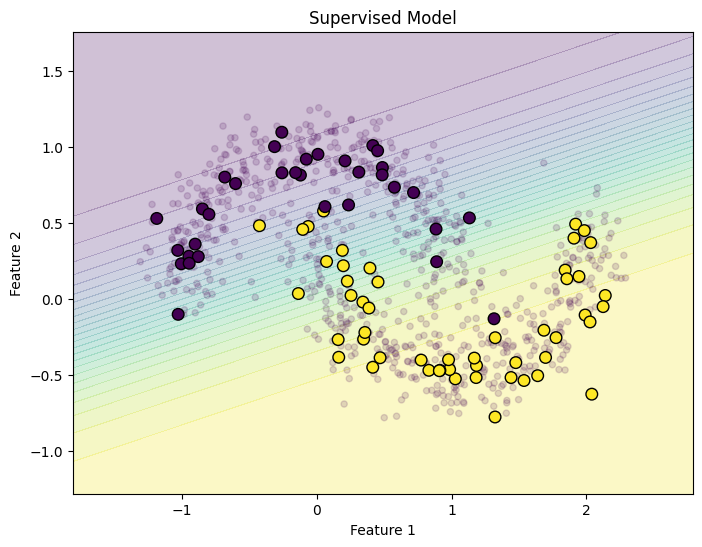

In [22]:
plot_decision_boundary(
    supervised_model,
    X_train,
    y_train_partial,
    "Supervised Model",
    labeled_mask
)

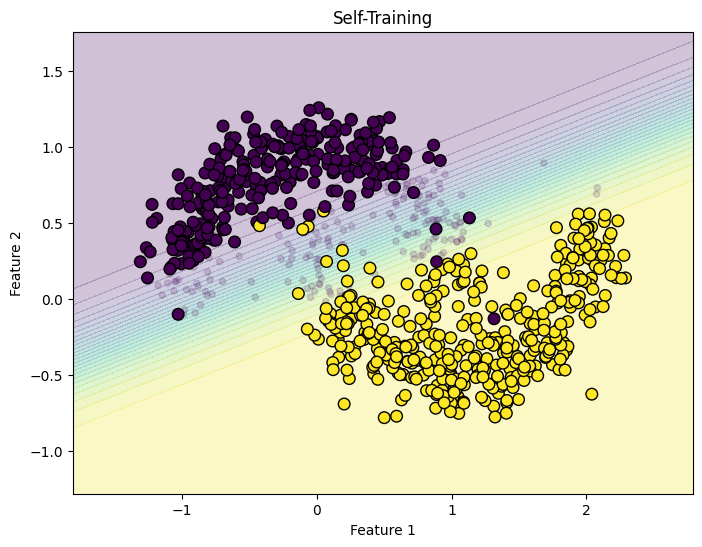

In [23]:
plot_decision_boundary(
    self_training_model,
    X_train,
    transduced_labels,
    "Self-Training",
    transduced_labels != -1
)

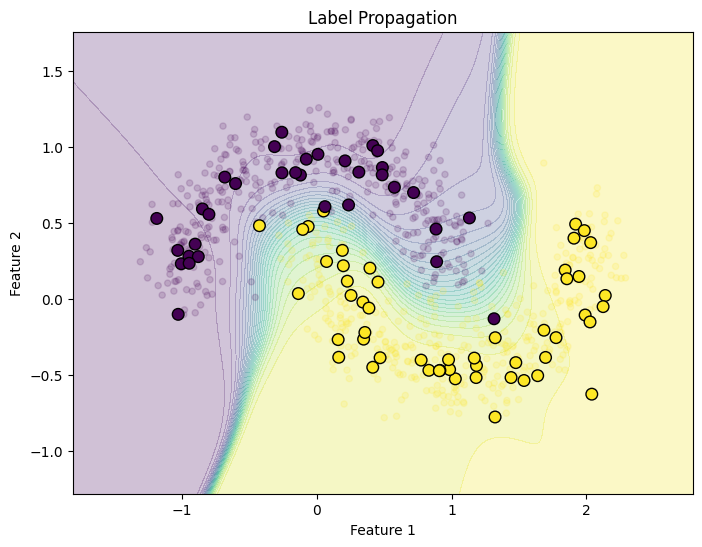

In [24]:
plot_decision_boundary(
    label_propagation_model,
    X_train,
    label_propagation_model.transduction_,
    "Label Propagation",
    y_train_partial != -1
)

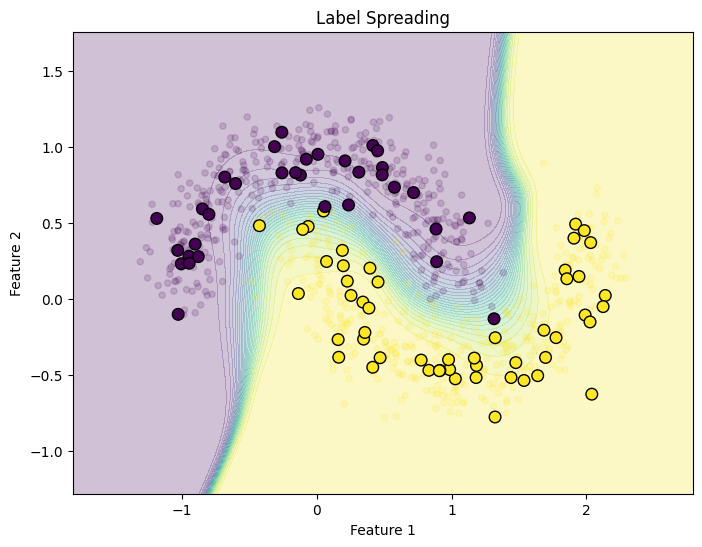

In [25]:
plot_decision_boundary(
    label_spreading_model,
    X_train,
    label_spreading_model.transduction_,
    "Label Spreading",
    y_train_partial != -1
)

## Failure Modes of Semi-Supervised Learning

Semi-supervised learning is not guaranteed to improve performance.

### 1. Incorrect Pseudo-Labels

If the initial model is poor, it can generate incorrect pseudo-labels.

These incorrect labels can then influence subsequent training.

---

### 2. Confirmation Bias

A model can reinforce its own mistakes:

$$
\text{prediction}
\rightarrow
\text{pseudo-label}
\rightarrow
\text{retraining}
\rightarrow
\text{reinforced prediction}
$$

---

### 3. Incorrect Cluster Assumption

If different classes occupy the same region of feature space, graph-based methods may propagate labels incorrectly.

---

### 4. Distribution Shift

The unlabeled data may come from a different distribution than the labeled data.

In that situation, unlabeled examples can actually hurt performance.

---

### 5. Poor Feature Representation

Graph-based SSL methods depend heavily on similarity between samples.

If the feature representation does not capture meaningful similarity, the graph structure may be misleading.

---

### 6. Class Imbalance

If one class dominates the unlabeled data, pseudo-labeling can amplify that imbalance.

---

### Important Principle

More unlabeled data does not automatically mean better performance.

The usefulness of unlabeled data depends on whether the assumptions underlying the SSL method are approximately valid.

## Practical Considerations

When applying semi-supervised learning to a real problem, consider:

### Label Quality

A small number of high-quality labels can sometimes be more valuable than many noisy labels.

### Confidence Threshold

Use conservative thresholds when pseudo-label errors are expensive.

### Validation Strategy

The validation set should contain reliable ground-truth labels.

### Data Distribution

Check whether labeled and unlabeled examples come from compatible distributions.

### Feature Representation

Similarity-based methods require meaningful representations.

### Computational Cost

Graph-based methods can become expensive as the number of samples grows.

For large datasets, methods based on neural networks, embeddings, or scalable pseudo-labeling strategies may be more appropriate.

## Key Concepts

### Semi-Supervised Learning

Learning from:

$$
\text{labeled data}
+
\text{unlabeled data}
$$

### Self-Training

Train a model and iteratively add confident predictions as pseudo-labels.

### Pseudo-Labeling

Use model predictions as temporary labels for unlabeled data.

### Label Propagation

Use graph connectivity to propagate labels from labeled nodes to unlabeled nodes.

### Label Spreading

Use graph-based diffusion while allowing softer label assignments.

### Confidence Threshold

Controls how confident a model must be before an unlabeled example is incorporated.

$$
\max_k P(y=k\mid x)\geq\tau
$$

# Summary

Semi-supervised learning is useful when labeled data is limited but unlabeled data is abundant.

The key idea is not simply to "use unlabeled data", but to exploit assumptions about the relationship between the input structure and the target labels.

The major ideas explored in this notebook were:

- The semi-supervised learning problem
- Smoothness, cluster, and manifold assumptions
- Self-training
- Pseudo-labeling
- Label propagation
- Label spreading
- Confidence thresholds
- The effect of labeled-data availability
- Decision-boundary analysis
- Failure modes

The most important lesson is:

> Unlabeled data is useful only when its structure provides reliable information about the target variable.

Semi-supervised learning therefore sits between supervised and unsupervised learning:

$$
\boxed{
\text{Supervised Learning}
\quad\leftrightarrow\quad
\text{Semi-Supervised Learning}
\quad\leftrightarrow\quad
\text{Unsupervised Learning}
}
$$